In [1]:
import numpy as np
import scipy.linalg as la
from joblib import Parallel, delayed
import time
import scipy.io as sio
import matplotlib.pyplot as plt  # 导入绘图库

def lead_SG(E, SGF_H00, SGF_H01):
    """
    计算半无限大电极的表面格林函数 (SRGF)
    基于 1984 J. Phys. F: Met. Phys. 14 1205
    对应 MATLAB 脚本中的 lead_SG / gr_l
    """
    m = SGF_H00.shape[0]
    Ef = E * np.eye(m)
    
    # 构造 2m x 2m 的转换矩阵 T_matrix
    T_matrix = np.zeros((2 * m, 2 * m), dtype=complex)
    T_matrix[m:2*m, 0:m] = np.eye(m)
    
    # MATLAB: T_matrix(1:m,1:m) = (SGF_H01)\(Ef-SGF_H00);
    inv_H01 = la.inv(SGF_H01)
    T_matrix[0:m, 0:m] = inv_H01 @ (Ef - SGF_H00)
    
    # MATLAB: T_matrix(1:m,m+1:2*m) = -(SGF_H01)\SGF_H01';
    T_matrix[0:m, m:2*m] = -inv_H01 @ SGF_H01.conj().T
    
    # 特征值分解
    T_eigenvalue, T_eigenvector = la.eig(T_matrix)
    
    # MATLAB: [~,I_order] = sort(T_eigenvalue); (对复数按模长排序)
    I_order = np.argsort(np.abs(T_eigenvalue))
    
    S_matrix1 = T_eigenvector[0:m, I_order[0:m]]
    S_matrix2 = T_eigenvector[m:2*m, I_order[0:m]]
    
    # MATLAB: SRGF = inv(Ef-SGF_H00 - SGF_H01*S_matrix1/(S_matrix2));
    # 注意: S_matrix1 / S_matrix2 在 MATLAB 中等价于 S_matrix1 * inv(S_matrix2)
    term = SGF_H01 @ S_matrix1 @ la.inv(S_matrix2)
    SRGF = la.inv(Ef - SGF_H00 - term)
    
    return SRGF

# 原代码在主函数中调用 gr_l，实际上对应的就是这个逻辑
gr_l = lead_SG

In [6]:
# ================= 系统与物理参数设置 =================
a = 1          # 晶格常数
M = 0.5        # 中心区(QAHI)的磁化/拓扑质量参数
Ms = -0.5      # 电极区(TSC)的磁化/拓扑质量参数
A = 1          # 沿x/y方向的自旋轨道耦合(SOC)强度
B = 1          # 动能项/有效质量相关的跳跃积分参数
muD = 0.0      # 中心区的化学势
muS = 1        # 超导电极区的化学势
G0P = 0.35     # 零温超导能隙相关参数
T_Tc = 0.001   # 约化温度 (T/Tc)
Delta = G0P * (1 - T_Tc**2) # 有限温度下的超导能隙
KBT = G0P * T_Tc / 3.5      # 玻尔兹曼常数乘以温度
NIMFQ = 1001   # 松原频率求和的最大截断次数
Etawn = 1e-4   # 频率求和的收敛阈值
Ny = 11        # 横向(y方向)的晶格格点数
Nx = 5         # 纵向(x方向)的晶格格点数
Ey = 0.0 * np.pi / ((Nx - 1) * (Ny - 1)) # 横向外加电场强度

# ================= 泡利矩阵与基底定义 =================
sigmax = np.array([[0, 1], [1, 0]], dtype=complex)
sigmay = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigmaz = np.array([[1, 0], [0, -1]], dtype=complex)
SIGM0 = np.kron(sigmaz, np.eye(2 * Ny))

def calculate_current_for_phi(phi_val):
    """
    计算特定相位差下的电流
    对应 MATLAB 中 parfor 的单次迭代
    """
    PHIL = np.pi * phi_val / 2
    PHIR = -np.pi * phi_val / 2
    
    # 1. 在位能(On-site energy)哈密顿量
    He = (Ms - 4*B) * sigmaz - muS * np.eye(2)
    Hh = -(Ms - 4*B) * sigmaz + muS * np.eye(2)
    
    # 2. 超导配对势哈密顿量
    HdeltaL = 1j * Delta * np.exp(1j * PHIL) * sigmay
    HdeltaR = 1j * Delta * np.exp(1j * PHIR) * sigmay
    
    # 3. 近邻跃迁哈密顿量
    Hex = -B * sigmaz - A / 2 * 1j * sigmax
    Hhx = B * sigmaz - A / 2 * 1j * sigmax
    Hey = -B * sigmaz - A / 2 * 1j * sigmay
    Hhy = B * sigmaz + A / 2 * 1j * sigmay
    
    # 4. 构建左电极 HL
    HL = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
    HHei = np.kron(np.diag(np.ones(Ny - 1), 1), Hey)
    HHhi = np.kron(np.diag(np.ones(Ny - 1), 1), Hhy)
    
    HL[0:2*Ny, 0:2*Ny] = np.kron(np.eye(Ny), He) + HHei + HHei.conj().T
    HL[2*Ny:4*Ny, 2*Ny:4*Ny] = np.kron(np.eye(Ny), Hh) + HHhi + HHhi.conj().T
    HL[0:2*Ny, 2*Ny:4*Ny] = np.kron(np.eye(Ny), HdeltaL)
    HL[2*Ny:4*Ny, 0:2*Ny] = np.kron(np.eye(Ny), HdeltaL.conj().T)
    
    # 5. 构建右电极 HR
    HR = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
    HR[0:2*Ny, 0:2*Ny] = np.kron(np.eye(Ny), He) + HHei + HHei.conj().T
    HR[2*Ny:4*Ny, 2*Ny:4*Ny] = np.kron(np.eye(Ny), Hh) + HHhi + HHhi.conj().T
    HR[0:2*Ny, 2*Ny:4*Ny] = np.kron(np.eye(Ny), HdeltaR)
    HR[2*Ny:4*Ny, 0:2*Ny] = np.kron(np.eye(Ny), HdeltaR.conj().T)
    
    # 6. 构建跃迁耦合矩阵 VD
    VD = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
    VD[0:2*Ny, 0:2*Ny] = np.kron(np.eye(Ny), Hex)
    VD[2*Ny:4*Ny, 2*Ny:4*Ny] = np.kron(np.eye(Ny), Hhx)
    
    # 7. 构建中心区哈密顿量 HD
    y_coords = np.linspace(-(Ny - 1) / 2, (Ny - 1) / 2, Ny)
    HEye = -Ey * np.kron(np.eye(2), np.diag(y_coords))
    HEyh = Ey * np.kron(np.eye(2), np.diag(y_coords))
    
    HDe = (M - 4*B) * sigmaz + muD * np.eye(2)
    HDh = -(M - 4*B) * sigmaz - muD * np.eye(2)
    
    HD = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
    HD[0:2*Ny, 0:2*Ny] = np.kron(np.eye(Ny), HDe) + HEye + HHei + HHei.conj().T
    HD[2*Ny:4*Ny, 2*Ny:4*Ny] = np.kron(np.eye(Ny), HDh) + HEyh + HHhi + HHhi.conj().T
    
    # ================= NEGF 与 松原频率求和计算电流 =================
    tempa = 0.0
    converged_NNA = NIMFQ
    
    for NNA in range(1, NIMFQ + 1):
        GFO_SN = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
        GFOD_SN = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
        
        for signFQ in [0, 1]:
            SIGNFQ = 2 * signFQ - 1
            E_val = 1j * SIGNFQ * np.pi * KBT * (2 * NNA - 1)
            
            # --- 右电极与左电极自能 ---
            SRGFR = gr_l(E_val, HR, VD)
            SigmaR = VD @ SRGFR @ VD.conj().T
            
            SRGFL = gr_l(E_val, HL, VD.conj().T)
            SigmaL = VD.conj().T @ SRGFL @ VD
            
            # --- 递归格林函数算法 ---
            I_4Ny = np.eye(4 * Ny)
            inv_base_L = la.inv(E_val * I_4Ny - HD - SigmaL)
            G_nnfullL1 = inv_base_L
            
            G_nnfullR = la.inv(E_val * I_4Ny - HD - SigmaR)
            
            # MATLAB 中 2:Nx-1 等价于 Python 的 range(2, Nx)
            for xR in range(2, Nx):
                MPA = G_nnfullR
                MPA = la.inv(E_val * I_4Ny - HD - VD @ MPA @ VD.conj().T)
                G_nnfullR = MPA
                
            # MATLAB: VD'/(E*eye(4*Ny)-HD-SigmaL)*VD -> VD' * inv(...) * VD
            G_nnfull = la.inv(E_val * I_4Ny - HD - VD @ G_nnfullR @ VD.conj().T - VD.conj().T @ inv_base_L @ VD)
            
            GF11 = G_nnfullL1
            GF22 = G_nnfull
            
            GFO_SN += GF22 @ VD.conj().T @ GF11
            GFOD_SN += GF11 @ VD @ GF22
            
        GFLO = 1j * GFO_SN
        GFLOD = 1j * GFOD_SN
        
        MPA = SIGM0 @ VD @ GFLO - SIGM0 @ GFLOD @ VD.conj().T
        tempc = np.real(np.trace(MPA))
        
        tempb = tempa
        
        # 避免除以0，同时判定收敛
        if np.abs(tempb) > 1e-15 and (np.abs(tempc) / np.abs(tempb)) < Etawn:
            converged_NNA = NNA
            break
            
        tempa = tempb + tempc
        
    return tempa, converged_NNA

In [8]:
import time
from datetime import datetime
from tqdm.auto import tqdm  # 使用 auto 可以在 Jupyter 中自动调用美观的 HTML 进度条
from joblib import Parallel, delayed
import scipy.io as sio
import numpy as np

if __name__ == "__main__":
    # ================= 扫描相位差主循环 =================
    Ndata1 = 1
    Ndata2 = 120
    PHI = np.linspace(0.0, 2.0, Ndata2)
    
    start_dt = datetime.now()
    print(f"[{start_dt.strftime('%Y-%m-%d %H:%M:%S')}] 开始并行计算...")
    start_time = time.time()
    
    # 1. 配置 Parallel 对象，设置 return_as="generator" 使其返回一个迭代器
    # 这样可以边计算边产出结果，非常适合配合 tqdm 使用
    parallel_runner = Parallel(n_jobs=24, return_as="generator")
    
    # 2. 构造延迟执行的任务列表
    tasks = (delayed(calculate_current_for_phi)(phi) for phi in PHI)
    
    # 3. 将任务传递给 Parallel，并用 tqdm 包裹外层来显示进度
    # total=Ndata2 告诉进度条总共有多少个任务
    results = list(tqdm(parallel_runner(tasks), total=Ndata2, desc="计算进度 (PHI)", colour="green"))
    
    # 解包结果
    SIX_list, SIXQ_list = zip(*results)
    SIX = np.array(SIX_list).reshape(Ndata1, Ndata2)
    SIXQ = np.array(SIXQ_list).reshape(Ndata1, Ndata2)
    
    end_time = time.time()
    end_dt = datetime.now()
    print(f"\n[{end_dt.strftime('%Y-%m-%d %H:%M:%S')}] 计算完成！")
    print(f"总耗时: {end_time - start_time:.2f} 秒")
    
    # 保存操作
    sio.savemat('liu3.mat', {'PHI': PHI, 'SIX': SIX, 'SIXQ': SIXQ})
    np.savez('liu3_python.npz', PHI=PHI, SIX=SIX, SIXQ=SIXQ)
    print("数据已保存为 liu3.mat 和 liu3_python.npz")

[2026-04-10 20:34:25] 开始并行计算...


计算进度 (PHI):   0%|          | 0/120 [00:00<?, ?it/s]


[2026-04-10 20:35:36] 计算完成！
总耗时: 71.05 秒
数据已保存为 liu3.mat 和 liu3_python.npz


正在生成图表...


<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taoji\AppData\Local\Temp\ipykernel_976\81611531.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Phase Difference $\phi$ ($\pi$)')


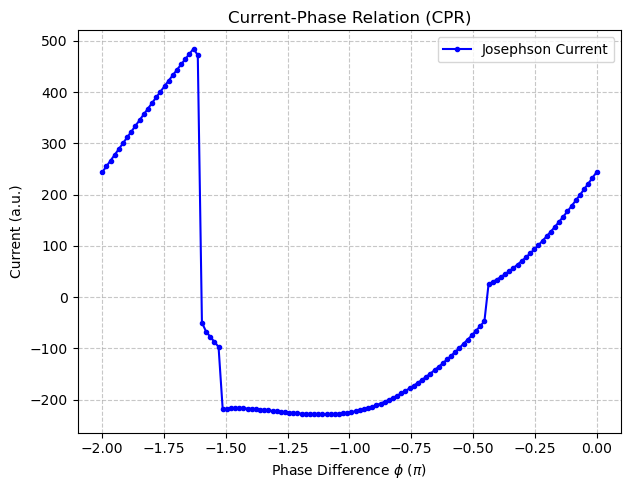

In [23]:
# ================= 绘图部分 =================
print("正在生成图表...")

# 设置画布大小
plt.figure(figsize=(12, 5))

# 图 1：约瑟夫森电流-相位关系 (Current-Phase Relation)
plt.subplot(1, 2, 1)
plt.plot(-PHI, SIX.flatten(), 'b.-', label='Josephson Current')
plt.xlabel('Phase Difference $\phi$ ($\pi$)')
plt.ylabel('Current (a.u.)')
plt.title('Current-Phase Relation (CPR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 自动调整子图间距并显示
plt.tight_layout()
#plt.ylim(-30,30)
plt.show()

In [3]:
#我的系统

import numpy as np
import scipy.linalg as la
from joblib import Parallel, delayed
import time
from datetime import datetime
from tqdm.auto import tqdm
import scipy.io as sio

# ================= 泡利矩阵与基底定义 =================
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
s0 = np.eye(2, dtype=complex)

# ================= 新的哈密顿量生成子函数 =================
def h_k(m, B, a):
    return (m - 4 * B / (a**2)) * sz

def h_x(B, a, A):
    return (B / (a**2)) * sz - (1j / 2) * A * sx

def h_y(B, a, A):
    return (B / (a**2)) * sz - (1j / 2) * A * sy

# ================= 系统与物理参数设置 (使用新代码参数) =================
a = 1
m = 0.5           # 统一的磁化/拓扑质量参数
A = 1  
B = 1  

delta = 0.1
T_Tc = 1e-4
# 新的超导能隙与温度设定
Delta = delta * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
KBT = 2 * delta * T_Tc / 3.5

Ny = 11           # 横向格点数 (原 yshumu)
Nx = 5            # 纵向格点数 (保留原设定)

uN = 0            # 中心区基础化学势
uS = 0.03         # 电极区基础化学势
Ey = 0.007 / Ny * 0.9 # 横向电场强度

NIMFQ = 3001      # 松原频率求和的最大截断次数
Etawn = 1e-4      # 频率求和的收敛阈值

# === 预先计算依赖 y 坐标的化学势梯度 ===
y_coords = np.arange(Ny) - Ny / 2
uN_set = uN - Ey * 0 * y_coords   # 中心区化学势分布 (设电场为0)
uS_set = uS - Ey * y_coords       # 电极区化学势分布

# SIGM0 继续使用原有的电子-空穴大分块基底，用于计算电流
SIGM0 = np.kron(sz, np.eye(2 * Ny))

# 提前提取出基础动能项，避免在循环中重复计算
He_base = h_k(m, B, a)
Hh_base = -He_base.conj()  # 根据新代码逻辑提取出的空穴项

Hey = h_y(B, a, A)
Hhy = -Hey.conj()

Hex = h_x(B, a, A)
Hhx = -Hex.conj()

# 提前构造好 Y 方向的跃迁矩阵 (仅空间部分)
HHei = np.kron(np.diag(np.ones(Ny - 1), 1), Hey)
HHhi = np.kron(np.diag(np.ones(Ny - 1), 1), Hhy)


def calculate_current_for_phi(phi_val):
    """
    计算特定相位差下的电流 (严格使用原有的 Nambu 大块基底)
    """
    PHIL = np.pi * phi_val / 2
    PHIR = -np.pi * phi_val / 2
    
    # ================= 构造左右电极及中心区 =================
    
    # --- 1. 构建左电极 HL ---
    HL = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
    
    # 利用矩阵外积批量生成包含势能梯度的 On-site 项
    Lead_He_onsite = np.kron(np.eye(Ny), He_base) - np.kron(np.diag(uS_set), s0)
    Lead_Hh_onsite = np.kron(np.eye(Ny), Hh_base) + np.kron(np.diag(uS_set), s0)
    
    HL[0:2*Ny, 0:2*Ny] = Lead_He_onsite + HHei + HHei.conj().T
    HL[2*Ny:4*Ny, 2*Ny:4*Ny] = Lead_Hh_onsite + HHhi + HHhi.conj().T
    
    # 超导配对势
    DeltaL_mat = 1j * Delta * np.exp(1j * PHIL) * sy
    H_pair_L = np.kron(np.eye(Ny), DeltaL_mat)
    HL[0:2*Ny, 2*Ny:4*Ny] = H_pair_L
    HL[2*Ny:4*Ny, 0:2*Ny] = H_pair_L.conj().T

    # --- 2. 构建右电极 HR ---
    HR = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
    HR[0:2*Ny, 0:2*Ny] = Lead_He_onsite + HHei + HHei.conj().T
    HR[2*Ny:4*Ny, 2*Ny:4*Ny] = Lead_Hh_onsite + HHhi + HHhi.conj().T
    
    DeltaR_mat = 1j * Delta * np.exp(1j * PHIR) * sy
    H_pair_R = np.kron(np.eye(Ny), DeltaR_mat)
    HR[0:2*Ny, 2*Ny:4*Ny] = H_pair_R
    HR[2*Ny:4*Ny, 0:2*Ny] = H_pair_R.conj().T

    # --- 3. 构建跃迁耦合矩阵 VD ---
    VD = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
    VD[0:2*Ny, 0:2*Ny] = np.kron(np.eye(Ny), Hex)
    VD[2*Ny:4*Ny, 2*Ny:4*Ny] = np.kron(np.eye(Ny), Hhx)

    # --- 4. 构建中心区哈密顿量 HD ---
    HD = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
    Center_He_onsite = np.kron(np.eye(Ny), He_base) - np.kron(np.diag(uN_set), s0)
    Center_Hh_onsite = np.kron(np.eye(Ny), Hh_base) + np.kron(np.diag(uN_set), s0)
    
    HD[0:2*Ny, 0:2*Ny] = Center_He_onsite + HHei + HHei.conj().T
    HD[2*Ny:4*Ny, 2*Ny:4*Ny] = Center_Hh_onsite + HHhi + HHhi.conj().T
    
    
    # ================= NEGF 与 松原频率求和计算电流 =================
    tempa = 0.0
    converged_NNA = NIMFQ
    
    for NNA in range(1, NIMFQ + 1):
        GFO_SN = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
        GFOD_SN = np.zeros((4 * Ny, 4 * Ny), dtype=complex)
        
        for signFQ in [0, 1]:
            SIGNFQ = 2 * signFQ - 1
            E_val = 1j * SIGNFQ * np.pi * KBT * (2 * NNA - 1)
            
            # --- 右电极与左电极自能 ---
            SRGFR = gr_l(E_val, HR, VD)
            SigmaR = VD @ SRGFR @ VD.conj().T
            
            SRGFL = gr_l(E_val, HL, VD.conj().T)
            SigmaL = VD.conj().T @ SRGFL @ VD
            
            # --- 递归格林函数算法 ---
            I_4Ny = np.eye(4 * Ny)
            inv_base_L = la.inv(E_val * I_4Ny - HD - SigmaL)
            G_nnfullL1 = inv_base_L
            
            G_nnfullR = la.inv(E_val * I_4Ny - HD - SigmaR)
            
            for xR in range(2, Nx):
                MPA = G_nnfullR
                MPA = la.inv(E_val * I_4Ny - HD - VD @ MPA @ VD.conj().T)
                G_nnfullR = MPA
                
            G_nnfull = la.inv(E_val * I_4Ny - HD - VD @ G_nnfullR @ VD.conj().T - VD.conj().T @ inv_base_L @ VD)
            
            GF11 = G_nnfullL1
            GF22 = G_nnfull
            
            GFO_SN += GF22 @ VD.conj().T @ GF11
            GFOD_SN += GF11 @ VD @ GF22
            
        GFLO = 1j * GFO_SN
        GFLOD = 1j * GFOD_SN
        
        MPA = SIGM0 @ VD @ GFLO - SIGM0 @ GFLOD @ VD.conj().T
        tempc = np.real(np.trace(MPA))
        
        tempb = tempa
        
        # 避免除以0，同时判定收敛
        if np.abs(tempb) > 1e-15 and (np.abs(tempc) / np.abs(tempb)) < Etawn:
            converged_NNA = NNA
            break
            
        tempa = tempb + tempc
        
    return tempa, converged_NNA

# (请在这里接入前面写好的 gr_l 函数以及主运行模块 if __name__ == "__main__": ...)

[2026-04-10 20:55:14] 开始并行计算...


<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taoji\AppData\Local\Temp\ipykernel_24032\3601066777.py:46: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Phase Difference $\phi$ ($\pi$)')
C:\Users\taoji\AppData\Local\Temp\ipykernel_24032\3601066777.py:55: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Phase Difference $\phi$ ($\pi$)')


计算进度 (PHI):   0%|          | 0/21 [00:00<?, ?it/s]


[2026-04-10 20:55:55] 计算完成！
总耗时: 40.77 秒
正在生成图表...


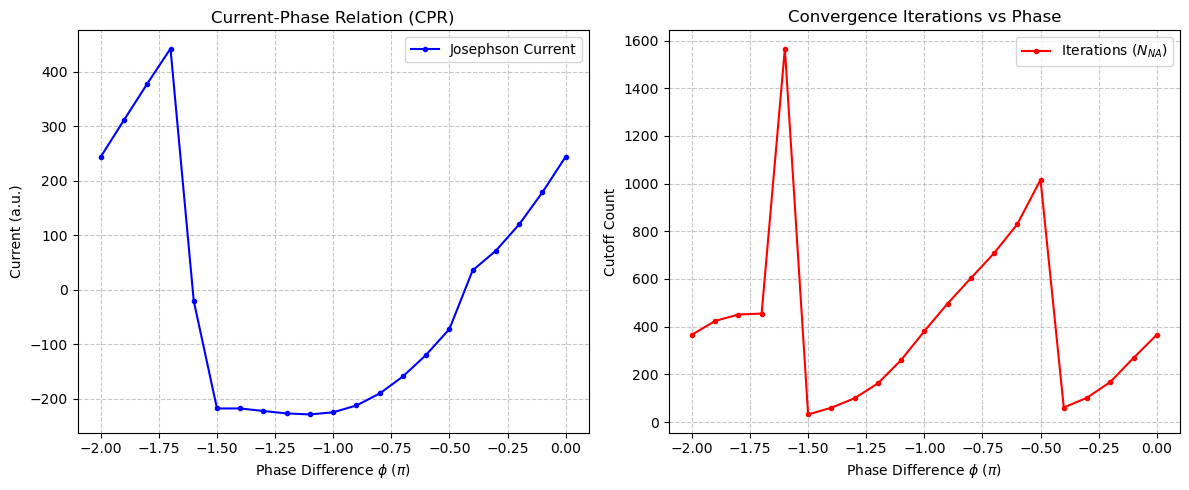

In [4]:
import time
from datetime import datetime
from tqdm.auto import tqdm  # 使用 auto 可以在 Jupyter 中自动调用美观的 HTML 进度条
from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt  # 导入绘图库

if __name__ == "__main__":
    # ================= 扫描相位差主循环 =================
    Ndata1 = 1
    Ndata2 = 21
    PHI = np.linspace(0.0, 2.0, Ndata2)
    
    start_dt = datetime.now()
    print(f"[{start_dt.strftime('%Y-%m-%d %H:%M:%S')}] 开始并行计算...")
    start_time = time.time()
    
    # 1. 配置 Parallel 对象，设置 return_as="generator" 使其返回一个迭代器
    parallel_runner = Parallel(n_jobs=24, return_as="generator")
    
    # 2. 构造延迟执行的任务列表
    tasks = (delayed(calculate_current_for_phi)(phi) for phi in PHI)
    
    # 3. 将任务传递给 Parallel，并用 tqdm 包裹外层来显示进度
    results = list(tqdm(parallel_runner(tasks), total=Ndata2, desc="计算进度 (PHI)", colour="green"))
    
    # 解包结果
    SIX_list, SIXQ_list = zip(*results)
    SIX = np.array(SIX_list).reshape(Ndata1, Ndata2)
    SIXQ = np.array(SIXQ_list).reshape(Ndata1, Ndata2)
    
    end_time = time.time()
    end_dt = datetime.now()
    print(f"\n[{end_dt.strftime('%Y-%m-%d %H:%M:%S')}] 计算完成！")
    print(f"总耗时: {end_time - start_time:.2f} 秒")
    
    # ================= 绘图部分 (不保存数据) =================
    print("正在生成图表...")
    
    # 设置画布大小
    plt.figure(figsize=(12, 5))
    
    # 图 1：约瑟夫森电流-相位关系 (Current-Phase Relation)
    plt.subplot(1, 2, 1)
    plt.plot(-PHI, SIX.flatten(), 'b.-', label='Josephson Current')
    plt.xlabel('Phase Difference $\phi$ ($\pi$)')
    plt.ylabel('Current (a.u.)')
    plt.title('Current-Phase Relation (CPR)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # 图 2：松原频率求和收敛所需的截断次数
    plt.subplot(1, 2, 2)
    plt.plot(-PHI, SIXQ.flatten(), 'r.-', label='Iterations ($N_{NA}$)')
    plt.xlabel('Phase Difference $\phi$ ($\pi$)')
    plt.ylabel('Cutoff Count')
    plt.title('Convergence Iterations vs Phase')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # 自动调整子图间距并显示
    plt.tight_layout()
    plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taoji\AppData\Local\Temp\ipykernel_976\3590843064.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Phase Difference $\phi$ ($\pi$)')


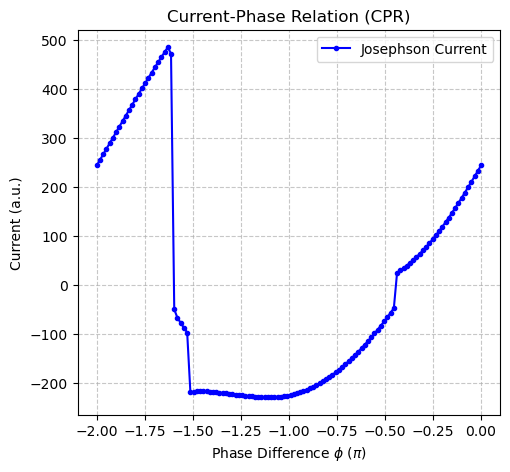

In [24]:
plt.figure(figsize=(12, 5))

# 图 1：约瑟夫森电流-相位关系 (Current-Phase Relation)
plt.subplot(1, 2, 1)
plt.plot(-PHI, SIX.flatten(), 'b.-', label='Josephson Current')
plt.xlabel('Phase Difference $\phi$ ($\pi$)')
plt.ylabel('Current (a.u.)')
plt.title('Current-Phase Relation (CPR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()